In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RXGate, RYGate, CZGate, MCXGate, RZGate, MCMT

import numpy as np

# Init Circuit Test

In [2]:
N = 2
B = 2
R = 2

In [3]:
rx_circuit = QuantumCircuit(N + R + 1)

rx_circuit.h(list(range(N + 1, N + 1 + R)))

# apply Rx rotation gates
for i in range(N):
	for r in range(R):
		gate = RXGate(np.pi / (2**r))
		rx_circuit.append(gate.control(1), (N + 1 + r, i))

# apply CNOT gate to target
rx_circuit.append(MCXGate(N), list(range(0, N+1)))

rx_circuit.draw()

┌───────┐┌─────────┐                         
q_0: ─────┤ Rx(π) ├┤ Rx(π/2) ├──────────────────────■──
          └───┬───┘└────┬────┘┌───────┐┌─────────┐  │  
q_1: ─────────┼─────────┼─────┤ Rx(π) ├┤ Rx(π/2) ├──■──
              │         │     └───┬───┘└────┬────┘┌─┴─┐
q_2: ─────────┼─────────┼─────────┼─────────┼─────┤ X ├
     ┌───┐    │         │         │         │     └───┘
q_3: ┤ H ├────■─────────┼─────────■─────────┼──────────
     ├───┤              │                   │          
q_4: ┤ H ├──────────────■───────────────────■──────────
     └───┘

In [4]:
transition_circ = QuantumCircuit(2*N + 1)
transition_circ.h(2*N)

for i in range(N):
	transition_circ.append(MCXGate(2), (i, 2*N, N + i))

transition_circ.draw()

q_0: ───────■───────
            │       
q_1: ───────┼────■──
          ┌─┴─┐  │  
q_2: ─────┤ X ├──┼──
          └─┬─┘┌─┴─┐
q_3: ───────┼──┤ X ├
     ┌───┐  │  └─┬─┘
q_4: ┤ H ├──■────■──
     └───┘

In [5]:
# R0lstar circuit
transformation_circ = QuantumCircuit(N + R + 1)

# append X gates
transformation_circ.x(list(range(N+1, N+R+1)))

# apply CZ gate
cz = RZGate(np.pi)
indices = list(range(0, N)) + list(range(N+1, N+R+1)) + [N]
transformation_circ.append(MCMT(cz, N+R, 1), indices)

# undo X gates
transformation_circ.x(list(range(N+1, N+R+1)))

transformation_circ.draw()

/var/folders/f0/g9bnvrbs7t15psm7b2d81gnm0000gn/T/ipykernel_84840/4227786876.py:10: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  transformation_circ.append(MCMT(cz, N+R, 1), indices)


┌───────┐     
q_0: ─────┤0      ├─────
          │       │     
q_1: ─────┤1      ├─────
          │       │     
q_2: ─────┤4 mcmt ├─────
     ┌───┐│       │┌───┐
q_3: ┤ X ├┤2      ├┤ X ├
     ├───┤│       │├───┤
q_4: ┤ X ├┤3      ├┤ X ├
     └───┘└───────┘└───┘

In [6]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
 
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

c = QuantumCircuit(5)

indices = list(range(0, N)) + list(range(N+1, N+R+1)) + [N]
c.append(MCMT(cz, N+R, 1), indices)

backend = FakeBrisbane()

pm = generate_preset_pass_manager(backend=backend)
phys = pm.run(c)

/var/folders/f0/g9bnvrbs7t15psm7b2d81gnm0000gn/T/ipykernel_84840/592064754.py:10: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  c.append(MCMT(cz, N+R, 1), indices)


In [ ]:
phys.draw(idle_wires=False)

In [2]:
def build_rx(N, R):
    rx_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for i in range(N):
        for r in range(R):
            gate = RXGate(np.pi / (2**r))
            rx_circuit.append(gate.control(1), (N + 1 + r, i))

    # apply CNOT gate to target
    rx_circuit.append(MCXGate(N), list(range(0, N+1)))

    return rx_circuit

def build_ry(N, R):
    ry_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for i in range(N):
        for r in range(R):
            gate = RYGate(np.pi / (2**r))
            ry_circuit.append(gate.control(1), (N + 1 + r, i))

    # apply CNOT gate to target
    ry_circuit.append(MCXGate(N), list(range(0, N+1)))

    return ry_circuit

def build_transition(N):
    transition_circ = QuantumCircuit(2*N + 1)

    for i in range(N):
        transition_circ.append(MCXGate(2), (i, 2*N, N + i))

    return transition_circ

def build_transformation(N, R):
    # R0lstar circuit
    transformation_circ = QuantumCircuit(N + R + 1)

    # append X gates
    transformation_circ.x(list(range(N+1, N+R+1)))

    # apply CZ gate
    cz = RZGate(np.pi)
    indices = list(range(0, N)) + list(range(N+1, N+R+1)) + [N]
    transformation_circ.append(MCMT(cz, N+R, 1), indices)   
    # undo X gates
    transformation_circ.x(list(range(N+1, N+R+1)))

    return transformation_circ

# Init entire circuit test

In [ ]:
def build_rx(N, R):
    rx_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for i in range(N):
        for r in range(R):
            gate = RXGate(np.pi / (2**r))
            rx_circuit.append(gate.control(1), (N + 1 + r, i))

    return rx_circuit

def build_ry(N, R):
    ry_circuit = QuantumCircuit(N + R + 1)

    # apply Rx rotation gates
    for i in range(N):
        for r in range(R):
            gate = RYGate(np.pi / (2**r))
            ry_circuit.append(gate.control(1), (N + 1 + r, i))

    return ry_circuit

def build_transition(N):
    transition_circ = QuantumCircuit(2*N + 1)

    for i in range(N):
        transition_circ.append(MCXGate(2), (i, 2*N, N + i))

    return transition_circ

# def build_transformation(N, R):
#   # R0lstar circuit
#   transformation_circ = QuantumCircuit(N + R + 1)

#   # append X gates
#   transformation_circ.x(list(range(N+1, N+R+1)))

#   # apply CZ gate
#   cz = RZGate(np.pi)
#   indices = list(range(0, N)) + list(range(N+1, N+R+1)) + [N]
#   transformation_circ.append(MCMT(cz, N+R, 1), indices)   
#   # undo X gates
#   transformation_circ.x(list(range(N+1, N+R+1)))

#   return transformation_circ

def build_r0lstar(R):
    # target + all of the R rotation controls
    r0lstar_circuit = QuantumCircuit(R)

    r0lstar_circuit.x(list(range(R)))
    r0lstar_circuit.mcrz(np.pi, list(range(R-1)), R-1)
    r0lstar_circuit.x(list(range(R)))

    return r0lstar_circuit


In [8]:
print(N+R+1)
print(list(range(N + 1, N + R - 1)))

6
[]


In [22]:
X = [[1, 0, 1], [0, 0, 0]]
R = 2

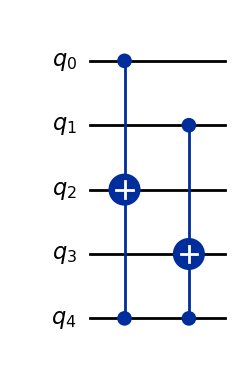

In [32]:
qc = build_transition(N)
qc.draw(output='mpl')

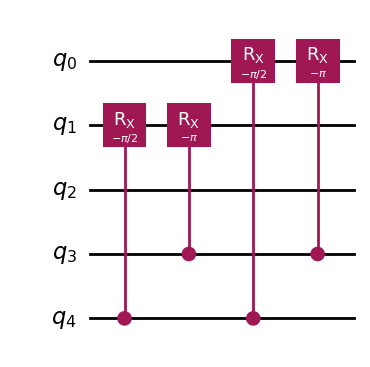

In [30]:
qc = build_rx(N, R)
temp = qc.inverse()
temp.draw(output='mpl')

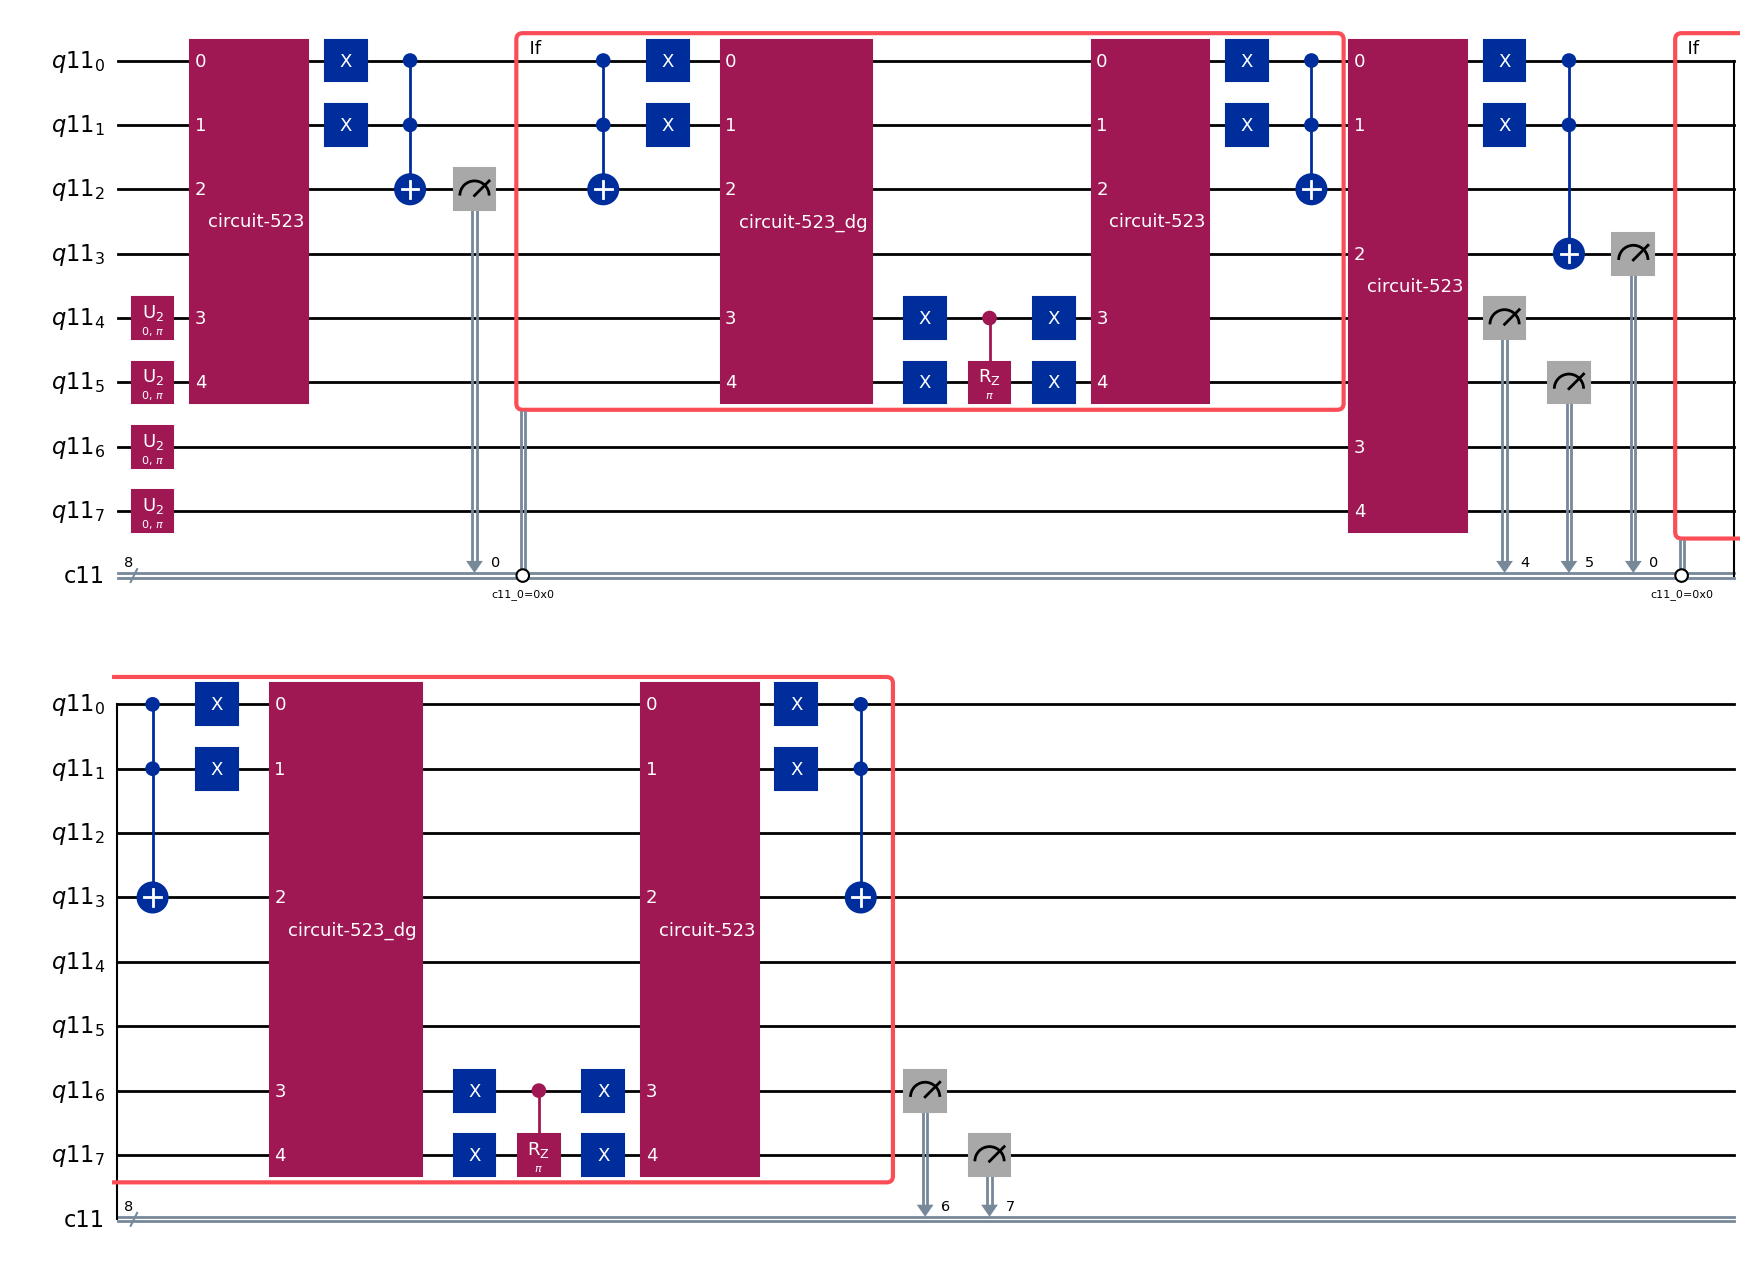

In [ ]:
# convert to NP array
X = np.array(X)

N = X.shape[0] # number of data points
B = X.shape[1] # number of bits

size = (N + 2 + 2*R) * B + B - 1

qr = QuantumRegister(size)
cr = ClassicalRegister(size)

# initialize circuit
circuit = QuantumCircuit(qr, cr)

circuit.h(list(range(N*B + 2*B, (N + 2 + 2*R) * B + B - 1)))

rx_block = build_rx(N, R).to_gate()
ry_block = build_ry(N, R).to_gate()
transition_block = build_transition(N).to_gate()
# transformation_block = build_transformation(N, R).to_gate()

r0lstar = build_r0lstar(R)

for i in range(B):
    # apply RX block (data + target + rotation)
    rx_target_index = N*B + 2*i
    rx_lanes = list(range(i * N, (i + 1) * N)) + [rx_target_index] + list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))

    # add the X-gates for bits with 0
    rx_bit_i = QuantumCircuit(rx_block.num_qubits)
    rx_bit_i.append(rx_block, list(range(rx_block.num_qubits)))
    for d in range(N):
        if X[d][i] == 0:
            # add X values for all bits with 0's
            rx_bit_i.x(d)

    # apply CNOT gate to target
    rx_bit_i.append(MCXGate(N), list(range(0, N+1)))

    circuit.append(rx_bit_i, rx_lanes)
    
    # measure
    circuit.measure(rx_target_index, cr[0])

    # OAA
    with circuit.if_test((cr[0], 0)):
        circuit.append(rx_bit_i.inverse(), rx_lanes)
        r0lstar_lanes = list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))
        circuit.append(r0lstar, r0lstar_lanes)
        circuit.append(rx_bit_i, rx_lanes)

    # apply Ry block
    ry_target_index = N*B + 2*i + 1
    ry_lanes = list(range(i * N, (i + 1) * N)) + [ry_target_index] + list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))

    # add the X gates for bits with 0
    ry_bit_i = QuantumCircuit(ry_block.num_qubits)
    ry_bit_i.append(rx_block, list(range(ry_block.num_qubits)))
    for d in range(N):
        if X[d][i] == 0:
            # add X values for all bits with 0's
            ry_bit_i.x(d)

    # apply CNOT gate to target
    ry_bit_i.append(MCXGate(N), list(range(0, N+1)))

    circuit.append(ry_bit_i, ry_lanes)
    
    # measure
    circuit.measure(ry_target_index, cr[0])

    # OAA
    with circuit.if_test((cr[0], 0)):
        circuit.append(ry_bit_i.inverse(), ry_lanes)
        r0lstar_lanes = list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))
        circuit.append(r0lstar, r0lstar_lanes)
        circuit.append(ry_bit_i, ry_lanes)
    
    if i != B - 1:
        # apply the transition from bit i to bit i + 1
        transition_lanes = list(range(i * N, (i + 2) * N)) + [size - B + i] # [consecutive lanes] + [control]
        # apply transition block
        circuit.append(transition_block, transition_lanes)
        
circuit.measure(qr[N*B + 2*B:N*B + 2*B + 2*R*B], cr[N*B + 2*B:N*B + 2*B + 2*R*B])

decomposed = circuit.decompose()
decomposed.draw(output='mpl')

In [60]:
def build_circuit(X, R):
	'''
	args:
		X: array of data points
		R: rotation precision
	returns:
		circuit: complete circuit
	'''
	# convert to NP array
	X = np.array(X)

	N = X.shape[0] # number of data points
	B = X.shape[1] # number of bits

	size = (N + 2 + 2*R) * B + B - 1

	qr = QuantumRegister(size)
	cr = ClassicalRegister(size, name='cr')
	xr = ClassicalRegister(1, name='xr')
	yr = ClassicalRegister(1, name='yr')

	# initialize circuit
	circuit = QuantumCircuit(qr, cr, xr, yr)

	circuit.h(list(range(N*B + 2*B, (N + 2 + 2*R) * B + B - 1)))

	rx_block = build_rx(N, R).to_gate()
	ry_block = build_ry(N, R).to_gate()
	transition_block = build_transition(N).to_gate()
	# transformation_block = build_transformation(N, R).to_gate()

	r0lstar = build_r0lstar(R)

	for i in range(B):
		# apply RX block (data + target + rotation)
		rx_target_index = N*B + 2*i
		rx_lanes = list(range(i * N, (i + 1) * N)) + [rx_target_index] + list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))

		# add the X-gates for bits with 0
		rx_bit_i = QuantumCircuit(rx_block.num_qubits)
		rx_bit_i.append(rx_block, list(range(rx_block.num_qubits)))
		for d in range(N):
			if X[d][i] == 0:
				# add X values for all bits with 0's
				rx_bit_i.x(d)

		# apply CNOT gate to target
		rx_bit_i.append(MCXGate(N), list(range(0, N+1)))

		circuit.append(rx_bit_i, rx_lanes)
		
		# measure
		circuit.measure(rx_target_index, xr)

		# OAA
		with circuit.if_test((xr, 0)):
			circuit.append(rx_bit_i.inverse(), rx_lanes)
			r0lstar_lanes = list(range(N*B + 2*B + 2*R*i, N*B + 2*B + 2*R*i + R))
			circuit.append(r0lstar, r0lstar_lanes)
			circuit.append(rx_bit_i, rx_lanes)

		# apply Ry block
		ry_target_index = N*B + 2*i + 1
		ry_lanes = list(range(i * N, (i + 1) * N)) + [ry_target_index] + list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))

		# add the X gates for bits with 0
		ry_bit_i = QuantumCircuit(ry_block.num_qubits)
		ry_bit_i.append(rx_block, list(range(ry_block.num_qubits)))
		for d in range(N):
			if X[d][i] == 0:
				# add X values for all bits with 0's
				ry_bit_i.x(d)

		# apply CNOT gate to target
		ry_bit_i.append(MCXGate(N), list(range(0, N+1)))

		circuit.append(ry_bit_i, ry_lanes)
		
		# measure
		circuit.measure(ry_target_index, yr)

		# OAA
		with circuit.if_test((yr, 0)):
			circuit.append(ry_bit_i.inverse(), ry_lanes)
			r0lstar_lanes = list(range(N*B + 2*B + 2*R*i + R, N*B + 2*B + 2*R*i + 2*R))
			circuit.append(r0lstar, r0lstar_lanes)
			circuit.append(ry_bit_i, ry_lanes)
		
		if i != B - 1:
			# apply the transition from bit i to bit i + 1
			transition_lanes = list(range(i * N, (i + 2) * N)) + [size - B + i] # [consecutive lanes] + [control]
			# apply transition block
			circuit.append(transition_block, transition_lanes)
			
	circuit.measure(qr, cr)

	return circuit

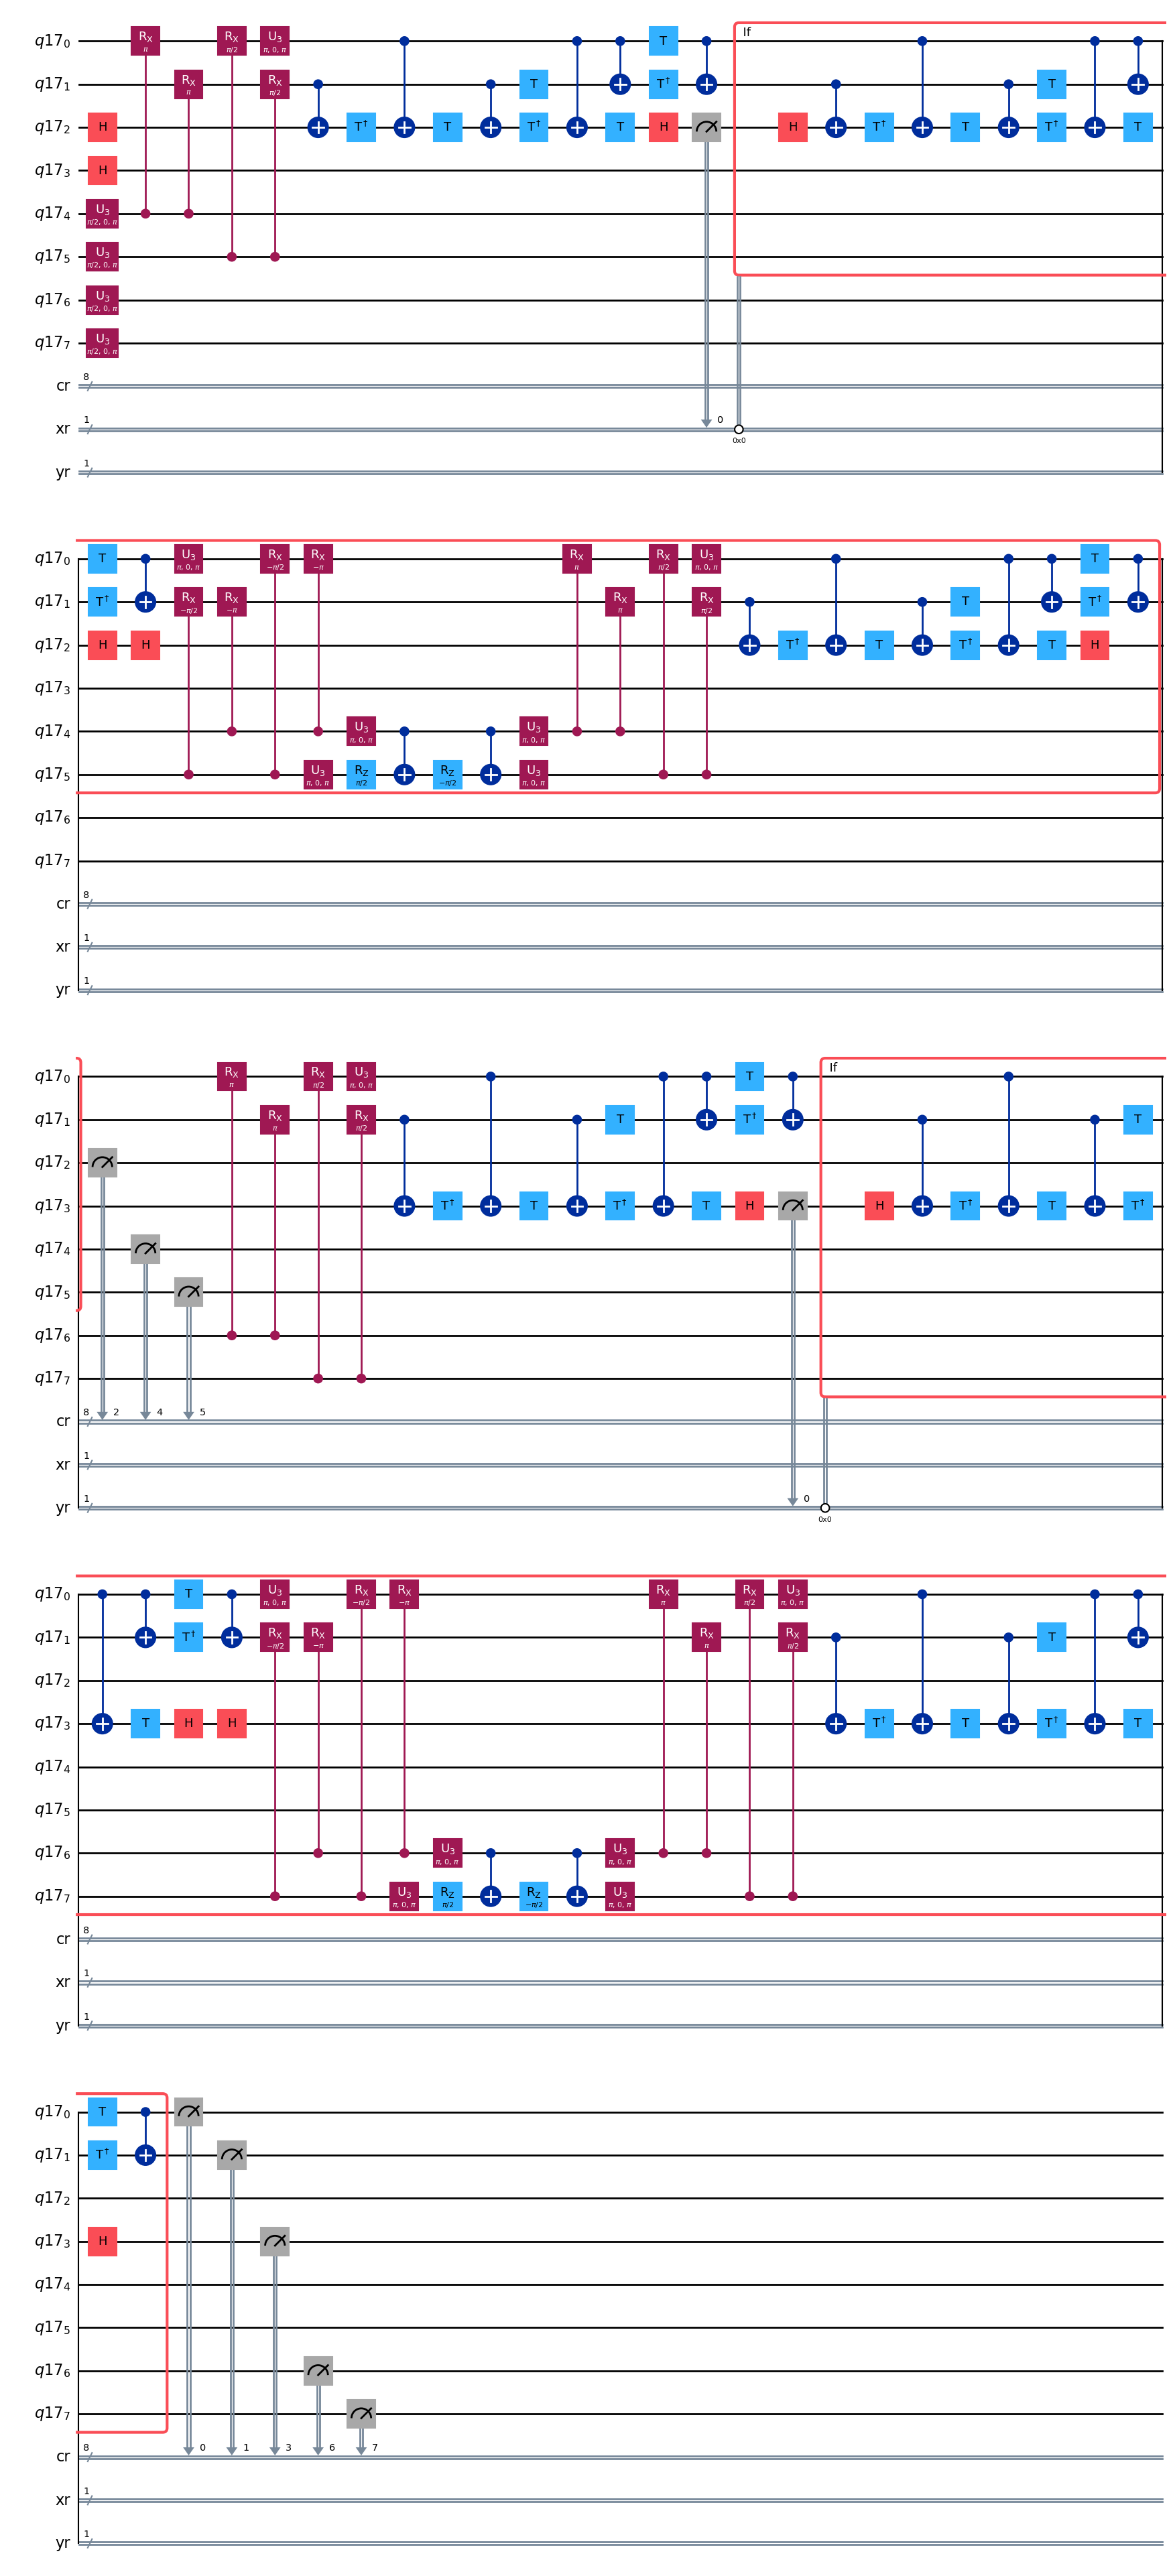

In [61]:
X = [[0], [1]]
R = 2
circuit = build_circuit(X, R)
decomposed = circuit.decompose(reps=2)
decomposed.draw(output='mpl')

In [38]:
# convert to NP array
X = np.array(X)

N = X.shape[0] # number of data points
B = X.shape[1] # number of bits

(N*B + 2*B) - (N*B + 2*B + 2*R*B)

-4

In [41]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = AerSimulator()
sampler = Sampler(backend=backend)

result = sampler.run([decomposed]).result()

/var/folders/f0/g9bnvrbs7t15psm7b2d81gnm0000gn/T/ipykernel_21802/3092817392.py:5: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


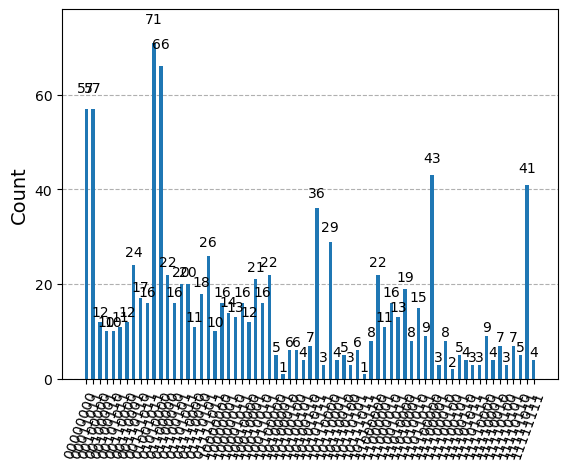

In [43]:
# counts = result[0].data.c12.get_counts()
counts = result[0].data.meas.get_counts()
from qiskit.visualization import plot_histogram

plot_histogram(counts)

In [47]:
def hellinger_distance(expected, actual):
    # calculates some error metric
    return np.sum(np.square(np.sqrt(expected) - np.sqrt(actual))) * 1 / np.sqrt(2)

In [54]:
def to_vector(dictionary:dict):
	N = len(list(dictionary.keys())[0])
	
	vector = np.zeros(N)
	
	for i in range(N):
		key = format(i, f'0{N}b')

		vector[i] = dictionary[key]

	vector = vector / np.sum(vector) # normalize

	return vector

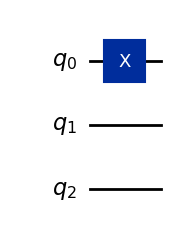

In [44]:
qc = QuantumCircuit(3)
qc.x(0)
qc.draw(output='mpl')

In [45]:
qc.measure_all()

backend = AerSimulator()
sampler = Sampler(backend=backend)

result = sampler.run([qc]).result()
result[0].data.meas.get_counts()

/var/folders/f0/g9bnvrbs7t15psm7b2d81gnm0000gn/T/ipykernel_21802/1187965836.py:4: DeprecationWarning: The 'backend' keyword arguments are deprecated as of qiskit-ibm-runtime 0.24.0 and will be removed no sooner than 3 months after the release date. Please use the 'mode' parameter instead.
  sampler = Sampler(backend=backend)


{'001': 1024}